In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [9]:
EUROSAT_PATH = "../dataset/EuroSAT"

In [10]:
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [11]:
dataset = ImageFolder(EUROSAT_PATH)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_subset, val_subset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [12]:
class TransformDataset(Dataset):

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        image = self.transform(image)

        return image, label

In [13]:
val_dataset = TransformDataset(
    val_subset,
    val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [14]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=10):

        super(BaselineCNN,self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256*8*8,512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512,num_classes)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [15]:
model = BaselineCNN()

model.load_state_dict(
    torch.load("../models/baseline_cnn.pth")
)

model = model.to(device)

model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [16]:
all_labels = []

all_predictions = []

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        all_labels.extend(labels.numpy())

        all_predictions.extend(
            predicted.cpu().numpy()
        )

In [17]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8978


In [18]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Precision : 0.8993
Recall    : 0.8978
F1 Score  : 0.8977


In [19]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.91      0.89      0.90       631
              Forest       0.83      0.95      0.89       582
HerbaceousVegetation       0.86      0.84      0.85       612
             Highway       0.94      0.85      0.89       525
          Industrial       0.94      0.98      0.96       484
             Pasture       0.88      0.80      0.84       396
       PermanentCrop       0.87      0.88      0.88       506
         Residential       0.98      0.94      0.96       606
               River       0.85      0.88      0.86       497
             SeaLake       0.92      0.94      0.93       561

            accuracy                           0.90      5400
           macro avg       0.90      0.90      0.90      5400
        weighted avg       0.90      0.90      0.90      5400



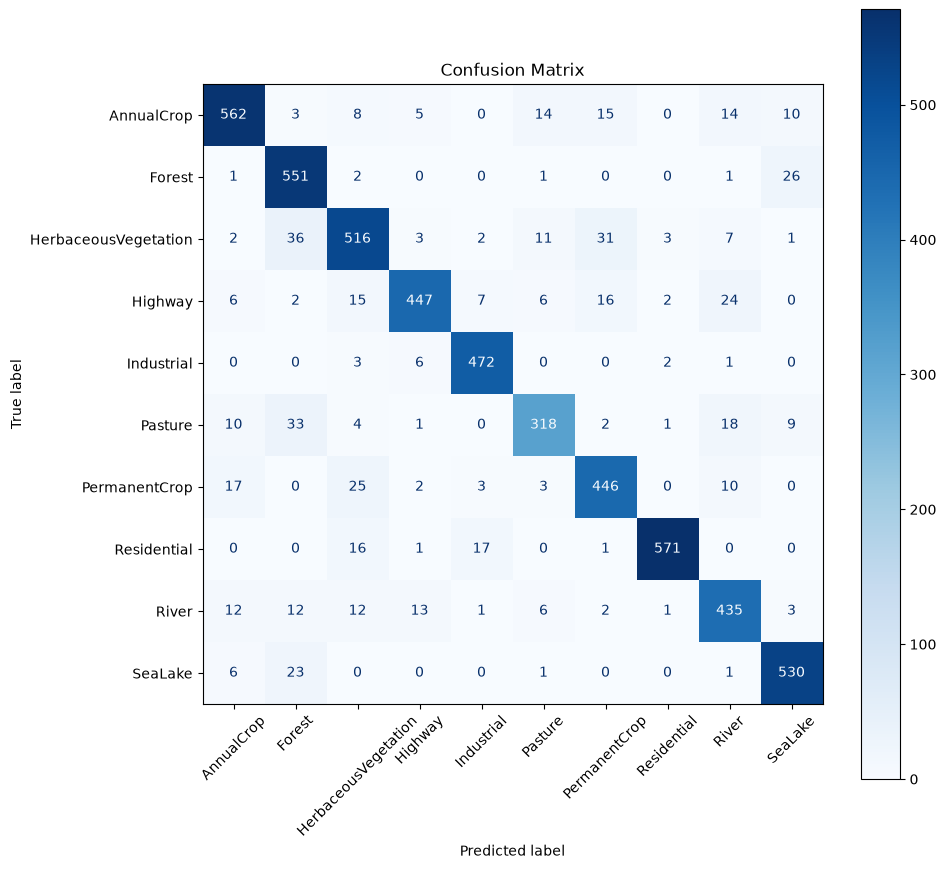

In [20]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()